# Part 2: CBM Hybrid Model, Analysis & Visualization
This notebook contains the second half of the project. It re-loads the dataset and
pre-trained models from Part 1 (.pth files), then runs the hybrid CBM experiments,
intervention analysis, and final comparison plots.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("collinmartin009/celeba-zip")

print("Path to dataset files:", path)

100%|██████████| 1.33G/1.33G [00:10<00:00, 140MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/collinmartin009/celeba-zip/versions/1


In [2]:
%pip install pytorch-lightning;
%pip install torchmetrics;
%pip install torchvision;
%pip install torch;
%pip install matplotlib;
%pip install numpy;
%pip install pandas;
%pip install seaborn;

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.6 MB/s eta 0:00:00


In [3]:
# from pathlib import Path
# from google.colab import drive
# drive.mount("/content/drive")

In [4]:
# CELEBA_ROOT = Path("/content/drive/MyDrive")
CELEBA_ROOT = path # Use with colab gpu

In [5]:
import os
import time
import pathlib


image_folder_path = pathlib.Path(CELEBA_ROOT) / "celeba" / "img_align_celeba"

# Retry mechanism for Google Drive access issues
max_retries = 3
retries = 0
num_files = 0
directory_accessible = False

while retries < max_retries:
    try:
        if image_folder_path.exists() and image_folder_path.is_dir():
            num_files = len([f for f in os.listdir(image_folder_path) if os.path.isfile(os.path.join(image_folder_path, f))])
            directory_accessible = True
            break
        else:
            print(f"Attempt {retries + 1}/{max_retries}: The directory {image_folder_path} does not exist or is not a directory.")
            break # Exit if the path itself is invalid, retrying won't help
    except OSError as e:
        retries += 1
        print(f"Attempt {retries}/{max_retries}: Failed to access directory. Error: {e}. Retrying in 5 seconds...")
        time.sleep(5)

if directory_accessible:
    print(f"Number of files in {image_folder_path}: {num_files}")
else:
    print(f"Could not access the directory {image_folder_path} after {max_retries} attempts.")

Number of files in /root/.cache/kagglehub/datasets/collinmartin009/celeba-zip/versions/1/celeba/img_align_celeba: 202599


In [6]:
import os
import torch
from torchvision.datasets import CelebA
from torch.utils.data import Subset
from torchvision import transforms

# 1. Setup Transforms (from your document)
transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Initialize the standard datasets (These contain the "Maps" of all 200k+ files)
# Note: We assign them to distinct variables for clarity
dataset = CelebA(root=CELEBA_ROOT, split="train", target_type="attr", transform=transform, download=False)
val_dataset = CelebA(root=CELEBA_ROOT, split="valid", target_type="attr", transform=transform, download=False)
test_dataset = CelebA(root=CELEBA_ROOT, split="test", target_type="attr", transform=transform, download=False)


print("--- Validation Complete ---")
print(f"Final Train Size: {len(dataset)}")
print(f"Final Valid Size: {len(val_dataset)}")
print(f"Final Test Size:  {len(test_dataset)}")

--- Validation Complete ---
Final Train Size: 162770
Final Valid Size: 19867
Final Test Size:  19962


## Constants and utility definitions from Part 1

['Smiling', 'Mouth_Slightly_Open', 'High_Cheekbones', 'Chubby', 'Narrow_Eyes', 'Bags_Under_Eyes', 'Big_Lips', 'Big_Nose', 'Pointy_Nose', 'Bushy_Eyebrows', 'Arched_Eyebrows'] 

Smiling                    47.97% positive
Mouth_Slightly_Open        48.22% positive
High_Cheekbones            45.24% positive
Chubby                     5.77% positive
Narrow_Eyes                11.59% positive
Bags_Under_Eyes            20.45% positive
Big_Lips                   24.09% positive
Big_Nose                   23.56% positive
Pointy_Nose                27.55% positive
Bushy_Eyebrows             14.37% positive
Arched_Eyebrows            26.59% positive


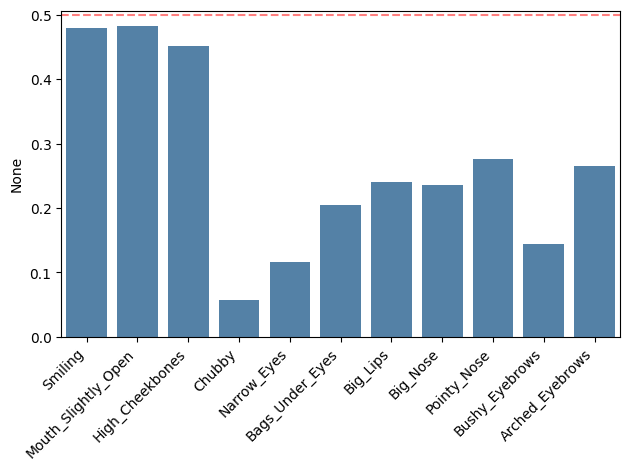

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

LABEL_NAME = 'Smiling'
CONCEPT_NAMES = ["Mouth_Slightly_Open", "High_Cheekbones",
                 "Chubby", "Narrow_Eyes", "Bags_Under_Eyes",
                 "Big_Lips", "Big_Nose", "Pointy_Nose",
                 "Bushy_Eyebrows", "Arched_Eyebrows"]

names = [LABEL_NAME] + CONCEPT_NAMES
print(names, "\n")
attr_names = list(dataset.attr_names)
idxs = [attr_names.index(n) for n in names]

props = dataset.attr[:, idxs].float().mean(dim=0)

for n, p in zip(names, props):
    print(f"{n:25s}  {p:.2%} positive")
    sns.barplot(x=names, y=props, color="steelblue")
plt.axhline(0.5, color="red", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [8]:
import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, val_losses, title=""):
    epochs = list(range(1, len(train_losses) + 1))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, marker="o", label="Training Loss")
    plt.plot(epochs, val_losses, marker="s", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    if len(epochs) > 1:
        plt.xticks(epochs)
    plt.show()

In [9]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import numpy as np
from sklearn.metrics import roc_auc_score
import torch.nn.functional as F

SMILING_IDX = dataset.attr_names.index('Smiling')  # should be 31

class BaselineClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])  # strip fc
        self.classifier = nn.Linear(512, 1)  # single binary output

    def forward(self, x):
        features = self.backbone(x)
        features = features.flatten(start_dim=1)  # (B, 512)
        return self.classifier(features)           # (B, 1)


def evaluate(model, dataloader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            smiling_labels = labels[:, SMILING_IDX].float()  # extract Smiling only

            logits = model(images).squeeze(1)  # (B,)
            probs = torch.sigmoid(logits)

            all_labels.append(smiling_labels.numpy())
            all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    preds = (all_probs >= 0.5).astype(int)
    accuracy = (preds == all_labels).mean()
    auroc = roc_auc_score(all_labels, all_probs)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test AUROC:    {auroc:.4f}")
    return accuracy, auroc

In [10]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

CONCEPT_IDXS = [list(dataset.attr_names).index(n) for n in CONCEPT_NAMES]
NUM_CONCEPTS = len(CONCEPT_NAMES)

class ConceptPredictor(nn.Module):
    def __init__(self, num_concepts=NUM_CONCEPTS):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.head = nn.Linear(512, num_concepts)

    def forward(self, x):
        features = self.backbone(x).flatten(start_dim=1)  # (B, 512)
        return self.head(features)

In [11]:
import torch

# Shape: (N, 10) — concept labels for all training samples
concept_labels = dataset.attr[:, CONCEPT_IDXS].float()

pos_counts = concept_labels.sum(dim=0)          # (10,)
neg_counts  = len(concept_labels) - pos_counts  # (10,)
pos_weight  = neg_counts / pos_counts.clamp(min=1)  # (10,) — ratio of neg:pos

print("pos_weight per concept:")
for name, w in zip(CONCEPT_NAMES, pos_weight):
    print(f"  {name:25s}  {w:.2f}")

pos_weight per concept:
  Mouth_Slightly_Open        1.07
  High_Cheekbones            1.21
  Chubby                     16.34
  Narrow_Eyes                7.63
  Bags_Under_Eyes            3.89
  Big_Lips                   3.15
  Big_Nose                   3.25
  Pointy_Nose                2.63
  Bushy_Eyebrows             5.96
  Arched_Eyebrows            2.76


In [12]:
class ConceptBottleneckModel(nn.Module):
    def __init__(self, num_concepts=NUM_CONCEPTS):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone     = nn.Sequential(*list(resnet.children())[:-1])
        self.concept_head = nn.Linear(512, num_concepts)  # x -> c
        self.label_head   = nn.Linear(num_concepts, 1)    # c -> y

    def forward(self, x):
        features       = self.backbone(x).flatten(start_dim=1)  # (B, 512)
        concept_logits = self.concept_head(features)             # (B, 10)
        concept_probs  = torch.sigmoid(concept_logits)           # (B, 10) -- keep interpretable
        label_logit    = self.label_head(concept_probs)          # (B, 1)
        return concept_logits, label_logit


In [13]:
def evaluate_cbm(model, dataloader, device):
    model.eval()
    all_y_labels, all_y_probs = [], []
    all_c_labels, all_c_preds = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images    = images.to(device)
            c_targets = labels[:, CONCEPT_IDXS].float()
            y_targets = labels[:, SMILING_IDX].float()

            concept_logits, label_logit = model(images)
            y_probs = torch.sigmoid(label_logit.squeeze(1)).cpu().numpy()
            c_preds = (torch.sigmoid(concept_logits) >= 0.5).int().cpu().numpy()

            all_y_labels.append(y_targets.numpy())
            all_y_probs.append(y_probs)
            all_c_labels.append(c_targets.numpy())
            all_c_preds.append(c_preds)

    all_y_labels = np.concatenate(all_y_labels)
    all_y_probs  = np.concatenate(all_y_probs)
    all_c_labels = np.concatenate(all_c_labels)
    all_c_preds  = np.concatenate(all_c_preds)

    y_preds  = (all_y_probs >= 0.5).astype(int)
    accuracy = (y_preds == all_y_labels).mean()
    auroc    = roc_auc_score(all_y_labels, all_y_probs)

    print("=== SMILING PREDICTION ===")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  AUROC:    {auroc:.4f}")

    print("\n=== CONCEPT PREDICTION ===")
    print(f"{'Concept':<25} {'Accuracy':>10} {'F1':>10}")
    print("-" * 47)
    accs, f1s = [], []
    for i, name in enumerate(CONCEPT_NAMES):
        acc = (all_c_preds[:, i] == all_c_labels[:, i]).mean()
        f1  = f1_score(all_c_labels[:, i], all_c_preds[:, i], zero_division=0)
        accs.append(acc)
        f1s.append(f1)
        print(f"{name:<25} {acc:>10.4f} {f1:>10.4f}")
    print("-" * 47)
    print(f"{'Macro Average':<25} {np.mean(accs):>10.4f} {np.mean(f1s):>10.4f}")

    return accuracy, auroc


## Load pre-trained models from Part 1
Make sure the .pth files from Part 1 are available in the working directory.

In [17]:
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create data loaders
train_loader = DataLoader(dataset,      batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,  batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Load baseline model
baseline_model = BaselineClassifier().to(device)
baseline_model.load_state_dict(torch.load('baseline_classifier.pth', map_location=device))
baseline_acc, baseline_auroc = evaluate(baseline_model, test_loader, device)
print(f'Baseline  -> Acc: {baseline_acc:.4f}, AUROC: {baseline_auroc:.4f}')

# Load concept predictor (needed to init CBM weights)
concept_model = ConceptPredictor().to(device)
concept_model.load_state_dict(torch.load('concept_predictor-2.pth', map_location=device))

# Load CBM model
cbm_model = ConceptBottleneckModel().to(device)
cbm_model.load_state_dict(torch.load('cbm_independent.pth', map_location=device))
cbm_acc, cbm_auroc = evaluate_cbm(cbm_model, test_loader, device)
print(f'CBM       -> Acc: {cbm_acc:.4f}, AUROC: {cbm_auroc:.4f}')


Test Accuracy: 0.9251
Test AUROC:    0.9808
Baseline  -> Acc: 0.9251, AUROC: 0.9808
=== SMILING PREDICTION ===
  Accuracy: 0.8752
  AUROC:    0.9448

=== CONCEPT PREDICTION ===
Concept                     Accuracy         F1
-----------------------------------------------
Mouth_Slightly_Open           0.9382     0.9373
High_Cheekbones               0.8626     0.8610
Chubby                        0.8187     0.3485
Narrow_Eyes                   0.7849     0.5148
Bags_Under_Eyes               0.8134     0.6460
Big_Lips                      0.6581     0.5875
Big_Nose                      0.7641     0.5931
Pointy_Nose                   0.7224     0.5905
Bushy_Eyebrows                0.8888     0.6625
Arched_Eyebrows               0.8029     0.7161
-----------------------------------------------
Macro Average                 0.8054     0.6457
CBM       -> Acc: 0.8752, AUROC: 0.9448


---
# Part 2 begins here

# CBM hybrid model

In [23]:
train_loader = DataLoader(dataset,      batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,  batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [24]:
class HybridCBM(nn.Module):
    """
    Hybrid Concept Bottleneck Model with side channel.

    y = f(c) + s(x)

    - f(c): concept-based classifier (concept_head -> sigmoid -> label_head)
    - s(x): side-channel head operating directly on backbone features
    - side_dropout: dropout applied ONLY to s(x) during training
    """
    def __init__(self, num_concepts=NUM_CONCEPTS, side_dropout=0.0):
        super().__init__()
        resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone     = nn.Sequential(*list(resnet.children())[:-1])
        self.concept_head = nn.Linear(512, num_concepts)   # x -> c
        self.label_head   = nn.Linear(num_concepts, 1)     # c -> y (concept path)

        # Side channel: backbone features -> label
        self.side_channel = nn.Sequential(
            nn.Dropout(p=side_dropout),
            nn.Linear(512, 1)
        )

        self.side_dropout_p = side_dropout

    def forward(self, x):
        features       = self.backbone(x).flatten(start_dim=1)    # (B, 512)
        concept_logits = self.concept_head(features)               # (B, 10)
        concept_probs  = torch.sigmoid(concept_logits)             # (B, 10)

        # Concept path
        label_logit_concept = self.label_head(concept_probs)       # (B, 1)

        # Side channel path
        label_logit_side    = self.side_channel(features)          # (B, 1)

        # Combined prediction: sum of logits
        label_logit = label_logit_concept + label_logit_side       # (B, 1)

        return concept_logits, label_logit, label_logit_concept, label_logit_side



In [25]:

def train_hybrid_cbm(model, train_loader, val_loader, device,
                     pos_weight, num_epochs=5, concept_loss_weight=0.5):
    """
    Joint training of the Hybrid CBM.
    Loss = BCE(y_hat, y) + concept_loss_weight * BCE(c_hat, c)
    """
    label_criterion   = nn.BCEWithLogitsLoss()
    concept_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    best_val_auroc = 0.0
    best_weights   = None
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images    = images.to(device)
            y_target  = labels[:, SMILING_IDX].float().to(device)
            c_targets = labels[:, CONCEPT_IDXS].float().to(device)

            optimizer.zero_grad()
            concept_logits, label_logit, _, _ = model(images)

            loss_label   = label_criterion(label_logit.squeeze(1), y_target)
            loss_concept = concept_criterion(concept_logits, c_targets)
            loss = loss_label + concept_loss_weight * loss_concept

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation
        model.eval()
        all_labels, all_probs = [], []
        val_total_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images    = images.to(device)
                y_target  = labels[:, SMILING_IDX].float().to(device)
                c_targets = labels[:, CONCEPT_IDXS].float().to(device)

                concept_logits, label_logit, _, _ = model(images)

                loss_label   = label_criterion(label_logit.squeeze(1), y_target)
                loss_concept = concept_criterion(concept_logits, c_targets)
                loss = loss_label + concept_loss_weight * loss_concept
                val_total_loss += loss.item()

                probs = torch.sigmoid(label_logit.squeeze(1)).cpu().numpy()
                all_labels.append(y_target.cpu().numpy())
                all_probs.append(probs)

        avg_val_loss = val_total_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        all_labels = np.concatenate(all_labels)
        all_probs  = np.concatenate(all_probs)
        val_auroc  = roc_auc_score(all_labels, all_probs)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Loss: {avg_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"Val AUROC: {val_auroc:.4f}")

        if val_auroc > best_val_auroc:
            best_val_auroc = val_auroc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            print(f"  --> New best saved (AUROC: {best_val_auroc:.4f})")

    model.load_state_dict(best_weights)
    print(f"\nTraining complete. Best Val AUROC: {best_val_auroc:.4f}")
    return model, train_losses, val_losses

In [26]:

def evaluate_hybrid(model, dataloader, device, verbose=True):
    """Evaluate hybrid CBM, return accuracy, auroc, concept metrics."""
    model.eval()
    all_y_labels, all_y_probs = [], []
    all_c_labels, all_c_preds = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images    = images.to(device)
            c_targets = labels[:, CONCEPT_IDXS].float()
            y_targets = labels[:, SMILING_IDX].float()

            concept_logits, label_logit, _, _ = model(images)
            y_probs = torch.sigmoid(label_logit.squeeze(1)).cpu().numpy()
            c_preds = (torch.sigmoid(concept_logits) >= 0.5).int().cpu().numpy()

            all_y_labels.append(y_targets.numpy())
            all_y_probs.append(y_probs)
            all_c_labels.append(c_targets.numpy())
            all_c_preds.append(c_preds)

    all_y_labels = np.concatenate(all_y_labels)
    all_y_probs  = np.concatenate(all_y_probs)
    all_c_labels = np.concatenate(all_c_labels)
    all_c_preds  = np.concatenate(all_c_preds)

    y_preds  = (all_y_probs >= 0.5).astype(int)
    accuracy = (y_preds == all_y_labels).mean()
    auroc    = roc_auc_score(all_y_labels, all_y_probs)

    macro_f1 = f1_score(all_c_labels, all_c_preds, average="macro", zero_division=0)

    if verbose:
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  AUROC:    {auroc:.4f}")
        print(f"  Concept Macro-F1: {macro_f1:.4f}")

    return accuracy, auroc, macro_f1




Training Hybrid CBM with side-channel dropout p=0.0
Epoch 1/1 | Loss: 0.4896 | Val Loss: 0.4412 | Val AUROC: 0.9850
  --> New best saved (AUROC: 0.9850)

Training complete. Best Val AUROC: 0.9850

--- Test Results (p=0.0) ---
  Accuracy: 0.9269
  AUROC:    0.9830
  Concept Macro-F1: 0.6517
Model saved to hybrid_cbm_p0.0.pth


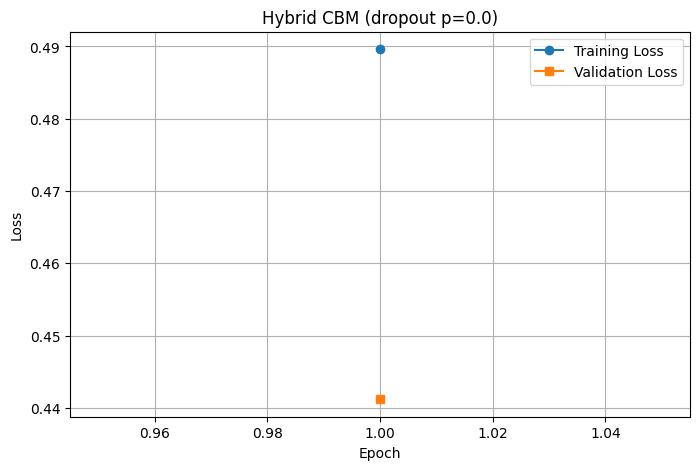


Training Hybrid CBM with side-channel dropout p=0.1
Epoch 1/1 | Loss: 0.4914 | Val Loss: 0.4369 | Val AUROC: 0.9849
  --> New best saved (AUROC: 0.9849)

Training complete. Best Val AUROC: 0.9849

--- Test Results (p=0.1) ---
  Accuracy: 0.9275
  AUROC:    0.9827
  Concept Macro-F1: 0.6404
Model saved to hybrid_cbm_p0.1.pth


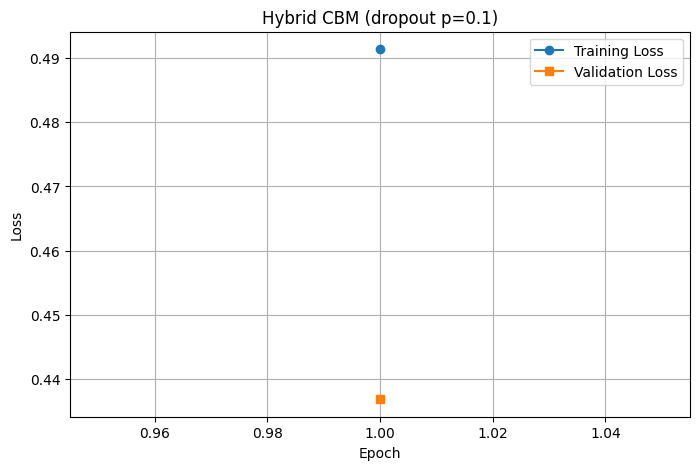


Training Hybrid CBM with side-channel dropout p=0.3
Epoch 1/1 | Loss: 0.4930 | Val Loss: 0.4364 | Val AUROC: 0.9850
  --> New best saved (AUROC: 0.9850)

Training complete. Best Val AUROC: 0.9850

--- Test Results (p=0.3) ---
  Accuracy: 0.9301
  AUROC:    0.9828
  Concept Macro-F1: 0.6467
Model saved to hybrid_cbm_p0.3.pth


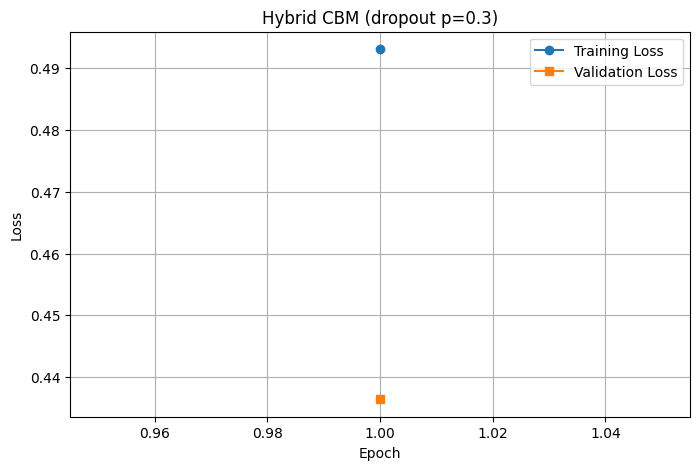


Training Hybrid CBM with side-channel dropout p=0.5
Epoch 1/1 | Loss: 0.4974 | Val Loss: 0.4340 | Val AUROC: 0.9855
  --> New best saved (AUROC: 0.9855)

Training complete. Best Val AUROC: 0.9855

--- Test Results (p=0.5) ---
  Accuracy: 0.9306
  AUROC:    0.9839
  Concept Macro-F1: 0.6516
Model saved to hybrid_cbm_p0.5.pth


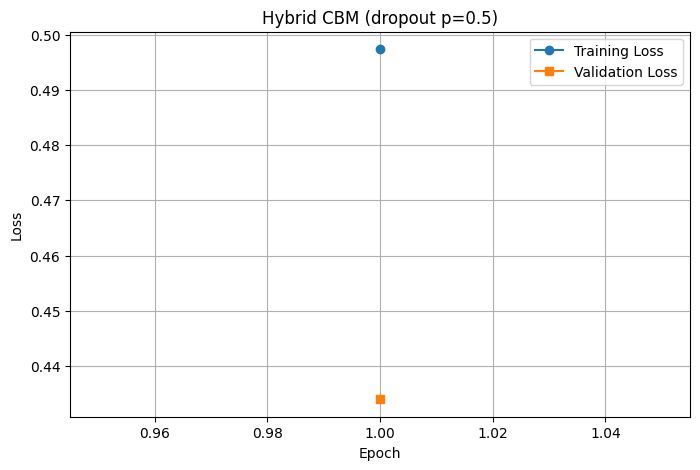


Training Hybrid CBM with side-channel dropout p=0.7
Epoch 1/1 | Loss: 0.5038 | Val Loss: 0.4346 | Val AUROC: 0.9854
  --> New best saved (AUROC: 0.9854)

Training complete. Best Val AUROC: 0.9854

--- Test Results (p=0.7) ---
  Accuracy: 0.9294
  AUROC:    0.9832
  Concept Macro-F1: 0.6404
Model saved to hybrid_cbm_p0.7.pth


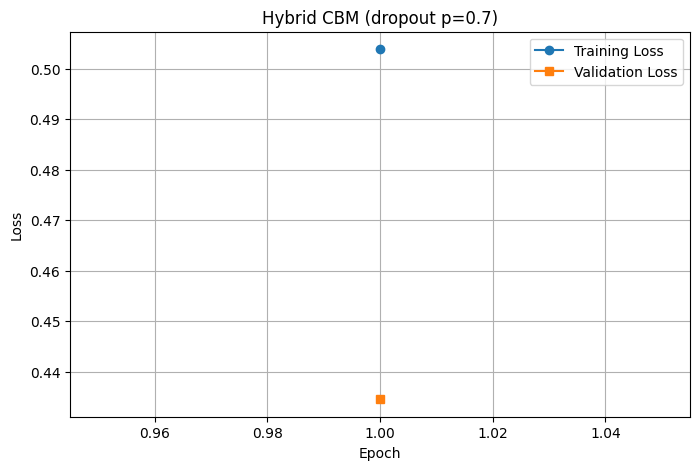


Training Hybrid CBM with side-channel dropout p=0.9
Epoch 1/1 | Loss: 0.5283 | Val Loss: 0.4348 | Val AUROC: 0.9852
  --> New best saved (AUROC: 0.9852)

Training complete. Best Val AUROC: 0.9852

--- Test Results (p=0.9) ---
  Accuracy: 0.9302
  AUROC:    0.9836
  Concept Macro-F1: 0.6439
Model saved to hybrid_cbm_p0.9.pth


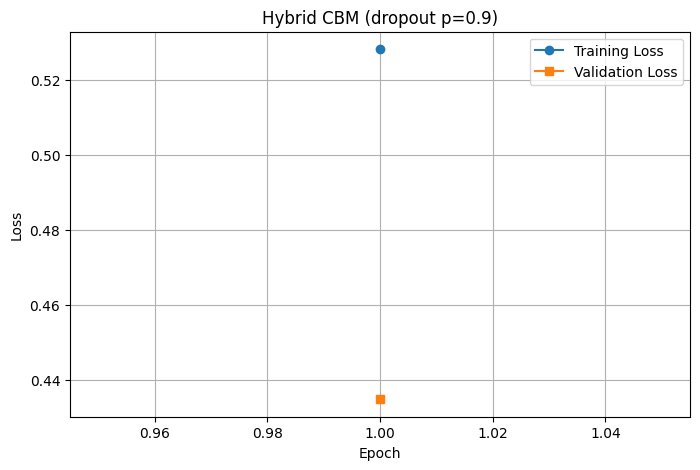

In [27]:

dropout_probs = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]
sweep_results = {}

for p in dropout_probs:
    print(f"\n{'='*60}")
    print(f"Training Hybrid CBM with side-channel dropout p={p}")
    print(f"{'='*60}")

    hybrid_model = HybridCBM(side_dropout=p).to(device)
    hybrid_model, h_train_losses, h_val_losses = train_hybrid_cbm(
        hybrid_model, train_loader, val_loader, device,
        pos_weight, num_epochs=1, concept_loss_weight=0.5
    )

    print(f"\n--- Test Results (p={p}) ---")
    acc, auroc, concept_f1 = evaluate_hybrid(hybrid_model, test_loader, device)

    sweep_results[p] = {
        "accuracy": acc,
        "auroc": auroc,
        "concept_f1": concept_f1,
        "model_state": {k: v.cpu().clone() for k, v in hybrid_model.state_dict().items()}
    }

    torch.save(hybrid_model.state_dict(), f"hybrid_cbm_p{p}.pth")
    print(f"Model saved to hybrid_cbm_p{p}.pth")

    plot_loss_curves(h_train_losses, h_val_losses, title=f"Hybrid CBM (dropout p={p})")

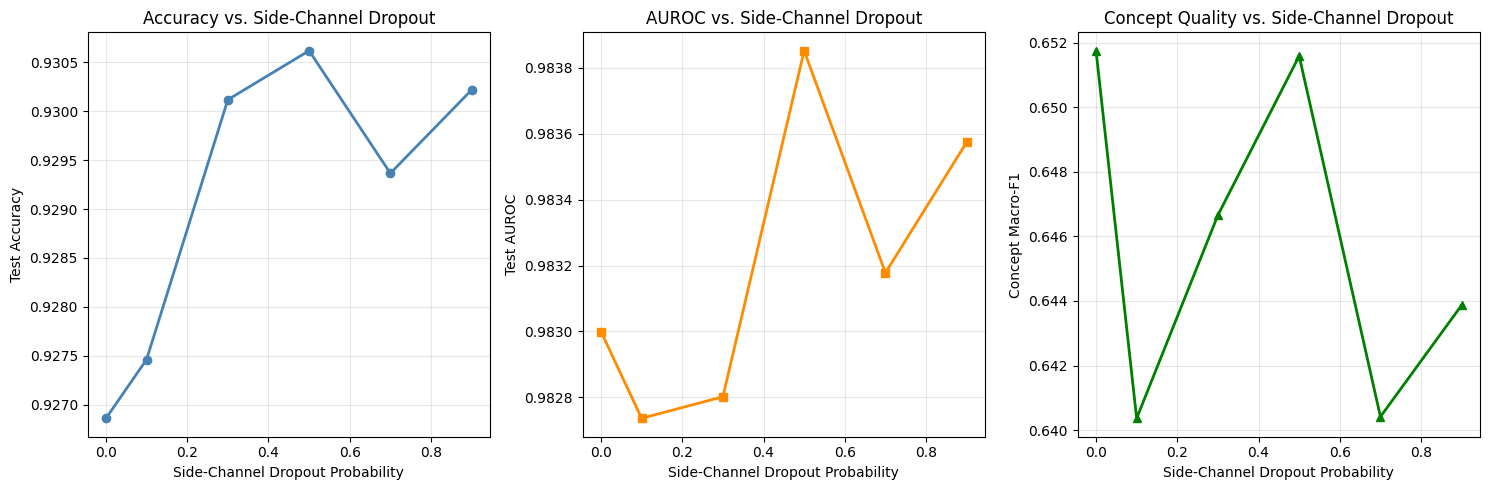


Dropout p      Accuracy      AUROC   Concept F1
----------------------------------------------
0.0              0.9269     0.9830       0.6517
0.1              0.9275     0.9827       0.6404
0.3              0.9301     0.9828       0.6467
0.5              0.9306     0.9839       0.6516
0.7              0.9294     0.9832       0.6404
0.9              0.9302     0.9836       0.6439


In [28]:

import matplotlib.pyplot as plt

ps   = sorted(sweep_results.keys())
accs   = [sweep_results[p]["accuracy"] for p in ps]
aurocs = [sweep_results[p]["auroc"]    for p in ps]
cf1s   = [sweep_results[p]["concept_f1"] for p in ps]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(ps, accs, "o-", color="steelblue", linewidth=2)
axes[0].set_xlabel("Side-Channel Dropout Probability")
axes[0].set_ylabel("Test Accuracy")
axes[0].set_title("Accuracy vs. Side-Channel Dropout")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ps, aurocs, "s-", color="darkorange", linewidth=2)
axes[1].set_xlabel("Side-Channel Dropout Probability")
axes[1].set_ylabel("Test AUROC")
axes[1].set_title("AUROC vs. Side-Channel Dropout")
axes[1].grid(True, alpha=0.3)

axes[2].plot(ps, cf1s, "^-", color="green", linewidth=2)
axes[2].set_xlabel("Side-Channel Dropout Probability")
axes[2].set_ylabel("Concept Macro-F1")
axes[2].set_title("Concept Quality vs. Side-Channel Dropout")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("dropout_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

# Print summary table
print(f"\n{'Dropout p':<12} {'Accuracy':>10} {'AUROC':>10} {'Concept F1':>12}")
print("-" * 46)
for p in ps:
    r = sweep_results[p]
    print(f"{p:<12.1f} {r['accuracy']:>10.4f} {r['auroc']:>10.4f} {r['concept_f1']:>12.4f}")


In [29]:

def concept_intervention_analysis(model, dataloader, device, model_type="cbm"):
    """
    For each concept, flip its predicted probability and measure:
    - avg_delta_prob: average absolute change in P(Smiling)
    - flip_rate: fraction of samples where predicted label changes

    model_type: "cbm" for ConceptBottleneckModel, "hybrid" for HybridCBM
    """
    model.eval()

    # Collect all predicted concept probs and features
    all_concept_probs = []
    all_features      = []
    all_y_labels      = []

    with torch.no_grad():
        for images, labels in dataloader:
            images   = images.to(device)
            features = model.backbone(images).flatten(start_dim=1)  # (B, 512)
            c_logits = model.concept_head(features)                 # (B, 10)
            c_probs  = torch.sigmoid(c_logits)                      # (B, 10)

            all_concept_probs.append(c_probs.cpu())
            all_features.append(features.cpu())
            all_y_labels.append(labels[:, SMILING_IDX].float())

    all_concept_probs = torch.cat(all_concept_probs, dim=0)  # (N, 10)
    all_features      = torch.cat(all_features, dim=0)       # (N, 512)
    all_y_labels      = torch.cat(all_y_labels, dim=0)       # (N,)

    # Move label_head to CPU for intervention (avoids OOM on large test sets)
    label_head_cpu = model.label_head.cpu()

    # For hybrid: also move side channel to CPU and compute side logits once
    side_logit = None
    if model_type == "hybrid":
        side_channel_cpu = model.side_channel.cpu()
        side_channel_cpu.eval()  # ensure dropout is off
        with torch.no_grad():
            side_logit = side_channel_cpu(all_features).squeeze(1)  # (N,)

    # Baseline prediction using predicted concepts
    with torch.no_grad():
        base_label_logit = label_head_cpu(all_concept_probs).squeeze(1)  # (N,)
        if model_type == "hybrid":
            base_label_logit = base_label_logit + side_logit
        base_prob = torch.sigmoid(base_label_logit)  # (N,)
        base_pred = (base_prob >= 0.5).int()

    results = {}

    for i, concept_name in enumerate(CONCEPT_NAMES):
        # Flip concept i: if prob > 0.5, set to 0; if <= 0.5, set to 1
        flipped_probs = all_concept_probs.clone()
        flipped_probs[:, i] = 1.0 - (all_concept_probs[:, i] >= 0.5).float()

        with torch.no_grad():
            new_label_logit = label_head_cpu(flipped_probs).squeeze(1)
            if model_type == "hybrid":
                new_label_logit = new_label_logit + side_logit
            new_prob = torch.sigmoid(new_label_logit)
            new_pred = (new_prob >= 0.5).int()

        delta_prob = (new_prob - base_prob).abs().mean().item()
        flip_rate  = (new_pred != base_pred).float().mean().item()

        results[concept_name] = {
            "avg_delta_prob": delta_prob,
            "flip_rate": flip_rate
        }

    # Move layers back to original device
    model.label_head.to(device)
    if model_type == "hybrid":
        model.side_channel.to(device)

    return results


# Run on pure CBM
print("=== Concept Interventions: Pure CBM (x -> c -> y) ===\n")
cbm_interventions = concept_intervention_analysis(
    cbm_model, test_loader, device, model_type="cbm"
)

print(f"{'Concept':<25} {'Avg |dP(Smiling)|':>20} {'Label Flip Rate':>18}")
print("-" * 65)
for name in CONCEPT_NAMES:
    r = cbm_interventions[name]
    print(f"{name:<25} {r['avg_delta_prob']:>20.4f} {r['flip_rate']:>18.4f}")

# Rank by intervention effect
ranked = sorted(cbm_interventions.items(), key=lambda x: x[1]["avg_delta_prob"], reverse=True)
print("\nRanked by intervention effect:")
for rank, (name, r) in enumerate(ranked, 1):
    print(f"  {rank}. {name} (avg delta={r['avg_delta_prob']:.4f}, flip_rate={r['flip_rate']:.4f})")


=== Concept Interventions: Pure CBM (x -> c -> y) ===

Concept                      Avg |dP(Smiling)|    Label Flip Rate
-----------------------------------------------------------------
Mouth_Slightly_Open                     0.2785             0.3401
High_Cheekbones                         0.4264             0.8400
Chubby                                  0.1244             0.1288
Narrow_Eyes                             0.0098             0.0114
Bags_Under_Eyes                         0.0197             0.0240
Big_Lips                                0.1284             0.1449
Big_Nose                                0.0756             0.0861
Pointy_Nose                             0.0193             0.0224
Bushy_Eyebrows                          0.0447             0.0521
Arched_Eyebrows                         0.0221             0.0232

Ranked by intervention effect:
  1. High_Cheekbones (avg delta=0.4264, flip_rate=0.8400)
  2. Mouth_Slightly_Open (avg delta=0.2785, flip_rate=0.3401)
 

In [30]:

print("\n=== Concept Interventions: Hybrid CBMs at Different Dropout Levels ===\n")

hybrid_intervention_results = {}

for p in [0.0, 0.5, 0.9]:
    # Reload the saved model
    hybrid_model = HybridCBM(side_dropout=p).to(device)
    hybrid_model.load_state_dict(
        torch.load(f"hybrid_cbm_p{p}.pth", map_location=device)
    )

    interventions = concept_intervention_analysis(
        hybrid_model, test_loader, device, model_type="hybrid"
    )
    hybrid_intervention_results[p] = interventions

    print(f"\n--- Hybrid CBM (dropout p={p}) ---")
    print(f"{'Concept':<25} {'Avg |dP(Smiling)|':>20} {'Label Flip Rate':>18}")
    print("-" * 65)
    for name in CONCEPT_NAMES:
        r = interventions[name]
        print(f"{name:<25} {r['avg_delta_prob']:>20.4f} {r['flip_rate']:>18.4f}")



=== Concept Interventions: Hybrid CBMs at Different Dropout Levels ===


--- Hybrid CBM (dropout p=0.0) ---
Concept                      Avg |dP(Smiling)|    Label Flip Rate
-----------------------------------------------------------------
Mouth_Slightly_Open                     0.0066             0.0062
High_Cheekbones                         0.0093             0.0074
Chubby                                  0.0039             0.0031
Narrow_Eyes                             0.0044             0.0037
Bags_Under_Eyes                         0.0012             0.0009
Big_Lips                                0.0003             0.0004
Big_Nose                                0.0046             0.0038
Pointy_Nose                             0.0050             0.0046
Bushy_Eyebrows                          0.0107             0.0101
Arched_Eyebrows                         0.0036             0.0029

--- Hybrid CBM (dropout p=0.5) ---
Concept                      Avg |dP(Smiling)|    Label Flip Ra

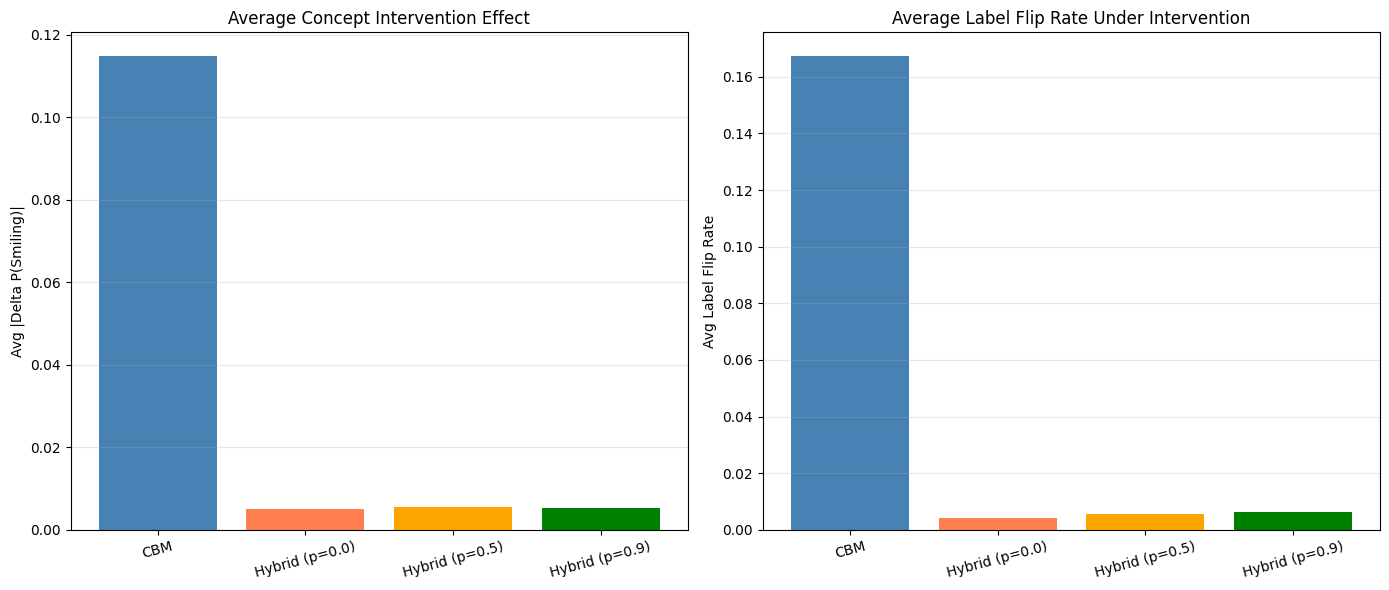

In [31]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average intervention effect across concepts for each model
models_to_compare = {"CBM": cbm_interventions}
for p in [0.0, 0.5, 0.9]:
    models_to_compare[f"Hybrid (p={p})"] = hybrid_intervention_results[p]

model_names = list(models_to_compare.keys())
avg_deltas  = []
avg_flips   = []
for name in model_names:
    interventions = models_to_compare[name]
    avg_d = np.mean([interventions[c]["avg_delta_prob"] for c in CONCEPT_NAMES])
    avg_f = np.mean([interventions[c]["flip_rate"] for c in CONCEPT_NAMES])
    avg_deltas.append(avg_d)
    avg_flips.append(avg_f)

x_pos = range(len(model_names))

axes[0].bar(x_pos, avg_deltas, color=["steelblue", "coral", "orange", "green"])
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, rotation=15)
axes[0].set_ylabel("Avg |Delta P(Smiling)|")
axes[0].set_title("Average Concept Intervention Effect")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(x_pos, avg_flips, color=["steelblue", "coral", "orange", "green"])
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, rotation=15)
axes[1].set_ylabel("Avg Label Flip Rate")
axes[1].set_title("Average Label Flip Rate Under Intervention")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("steerability_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


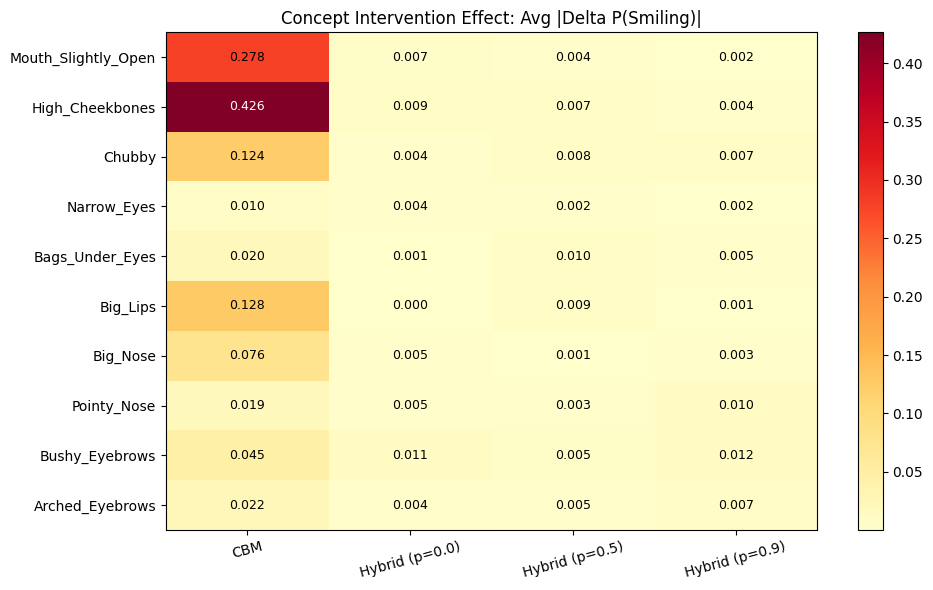

In [32]:

import pandas as pd

# Build a DataFrame: rows = concepts, columns = models
data = {}
for model_name, interventions in models_to_compare.items():
    data[model_name] = [interventions[c]["avg_delta_prob"] for c in CONCEPT_NAMES]

df = pd.DataFrame(data, index=CONCEPT_NAMES)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(df.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(df.columns)))
ax.set_xticklabels(df.columns, rotation=15)
ax.set_yticks(range(len(df.index)))
ax.set_yticklabels(df.index)
ax.set_title("Concept Intervention Effect: Avg |Delta P(Smiling)|")

# Annotate cells
for i in range(len(df.index)):
    for j in range(len(df.columns)):
        ax.text(j, i, f"{df.values[i, j]:.3f}", ha="center", va="center",
                color="black" if df.values[i, j] < df.values.max() * 0.7 else "white",
                fontsize=9)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("intervention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()



In [ ]:

def evaluate_and_return(model, dataloader, device):
    """Like evaluate() but returns (accuracy, auroc)."""
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            smiling_labels = labels[:, SMILING_IDX].float()
            logits = model(images).squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_labels.append(smiling_labels.numpy())
            all_probs.append(probs)
    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
    preds = (all_probs >= 0.5).astype(int)
    accuracy = (preds == all_labels).mean()
    auroc = roc_auc_score(all_labels, all_probs)
    return accuracy, auroc

print(f"\n{'='*70}")
print("FINAL COMPARISON TABLE")
print(f"{'='*70}")
print(f"{'Model':<35} {'Accuracy':>10} {'AUROC':>10} {'Steerable?':>12}")
print("-" * 70)

# Baseline
print(f"{'Baseline (x -> y)':<35} {baseline_acc:>10.4f} {baseline_auroc:>10.4f} {'No':>12}")

# Pure CBM
print(f"{'CBM Independent (x -> c -> y)':<35} {cbm_acc:>10.4f} {cbm_auroc:>10.4f} {'Yes':>12}")

# Hybrid models
for p in dropout_probs:
    r = sweep_results[p]
    steerable = "Partial" if p < 0.5 else "Yes" if p >= 0.7 else "Moderate"
    print(f"{'Hybrid CBM (p=' + str(p) + ')':<35} {r['accuracy']:>10.4f} {r['auroc']:>10.4f} {steerable:>12}")

print(f"{'='*70}")



FINAL COMPARISON TABLE
Model                                 Accuracy      AUROC   Steerable?
----------------------------------------------------------------------
Baseline (x -> y)                       0.9251     0.9808           No
CBM Independent (x -> c -> y)           0.8752     0.9448          Yes
Hybrid CBM (p=0.0)                      0.9269     0.9830      Partial
Hybrid CBM (p=0.1)                      0.9275     0.9827      Partial
Hybrid CBM (p=0.3)                      0.9301     0.9828      Partial
Hybrid CBM (p=0.5)                      0.9306     0.9839     Moderate
Hybrid CBM (p=0.7)                      0.9294     0.9832          Yes
Hybrid CBM (p=0.9)                      0.9302     0.9836          Yes


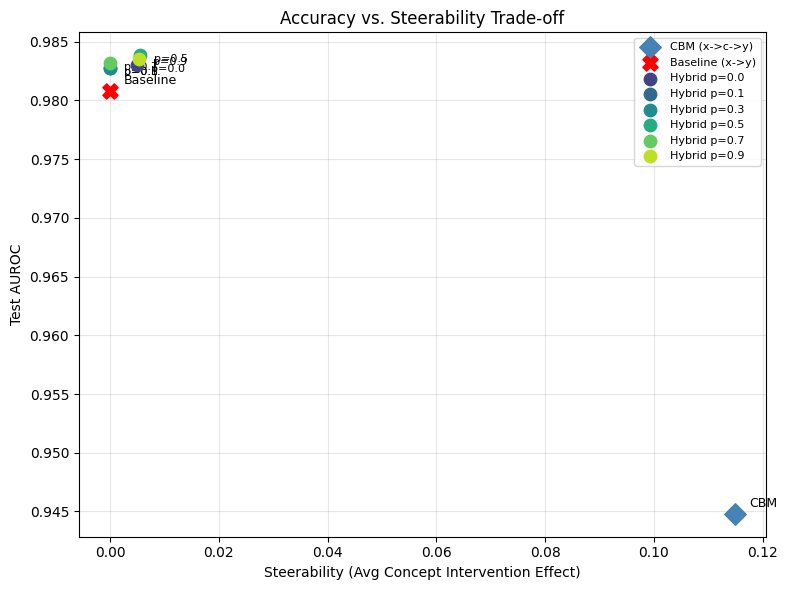

In [34]:

fig, ax = plt.subplots(figsize=(8, 6))

# CBM point
cbm_steer = np.mean([cbm_interventions[c]["avg_delta_prob"] for c in CONCEPT_NAMES])
ax.scatter(cbm_steer, cbm_auroc, s=120, marker="D", color="steelblue",
           label="CBM (x->c->y)", zorder=5)
ax.annotate("CBM", (cbm_steer, cbm_auroc), textcoords="offset points",
            xytext=(10, 5), fontsize=9)

# Baseline (steerability = 0, no concept layer)
ax.scatter(0, baseline_auroc, s=120, marker="X", color="red",
           label="Baseline (x->y)", zorder=5)
ax.annotate("Baseline", (0, baseline_auroc), textcoords="offset points",
            xytext=(10, 5), fontsize=9)

# Hybrid models
colors_hybrid = plt.cm.viridis(np.linspace(0.2, 0.9, len(dropout_probs)))
for i, p in enumerate(dropout_probs):
    r = sweep_results[p]
    if p in hybrid_intervention_results:
        steer = np.mean([hybrid_intervention_results[p][c]["avg_delta_prob"]
                         for c in CONCEPT_NAMES])
    else:
        steer = 0  # placeholder if not computed
    ax.scatter(steer, r["auroc"], s=80, color=colors_hybrid[i],
               label=f"Hybrid p={p}", zorder=4)
    ax.annotate(f"p={p}", (steer, r["auroc"]), textcoords="offset points",
                xytext=(10, -5), fontsize=8)

ax.set_xlabel("Steerability (Avg Concept Intervention Effect)")
ax.set_ylabel("Test AUROC")
ax.set_title("Accuracy vs. Steerability Trade-off")
ax.legend(loc="best", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("accuracy_vs_steerability.png", dpi=150, bbox_inches="tight")
plt.show()
